In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


In [2]:
# load a dataset
df = pd.read_csv("Churn.csv")

print("data load sucsesfully")

print(df.head())

print("\n data shape : " , df.shape)
print("\n colums :" , df.columns)

print("\n find nissing value \n" )
print(df.isnull().sum())

print("\n tyoe of the data")
print(df.dtypes)


df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors="coerce")
# converting TotalCharges may introduce NaN values (empty strings, etc.)
# drop any rows containing nulls so that downstream ML code doesn't fail
nan_count = df['TotalCharges'].isna().sum()
if nan_count > 0:
    print(
        f"TotalCharges conversion generated {nan_count} NaNs; dropping those rows.")
    df = df.dropna(subset=['TotalCharges'])

# remove identifier column
df.drop("customerID", axis=1, inplace=True)
print("\n Final Dataset Shape : ", df.shape)

data load sucsesfully
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovie

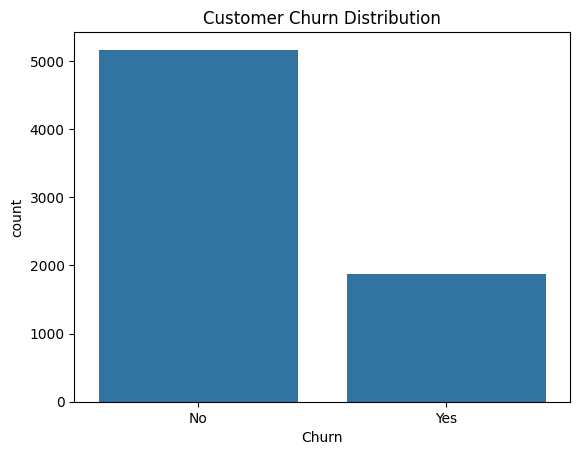

In [3]:
plt.Figure(figsize=(6,4))
sns.countplot(x = "Churn" , data= df)

plt.title("Customer Churn Distribution")
plt.show()

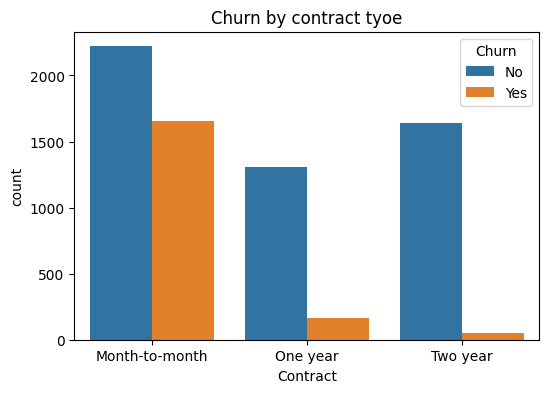

In [4]:
plt.figure(figsize=(6,4))
sns.countplot(x = "Contract" , hue="Churn" , data= df)

plt.title("Churn by contract tyoe")
plt.show()


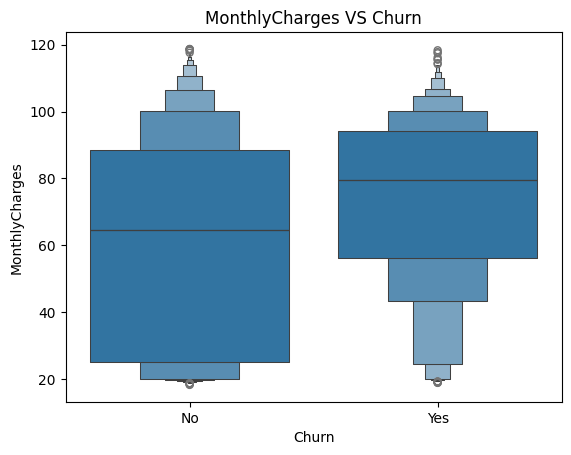

In [5]:
plt.Figure(figsize=(6,4))
sns.boxenplot(x = "Churn" , y = "MonthlyCharges" , data= df)

plt.title("MonthlyCharges VS Churn")
plt.show()

In [6]:
df["Churn"] = (df["Churn"].astype(str)
                        .str.strip()          # remove whitespace
                        .map({"Yes": 1, "No": 0}))
churn_nan = df["Churn"].isna().sum()
if churn_nan > 0:
    print(
        f"Found {churn_nan} rows where Churn could not be encoded; dropping them.")
    df = df.dropna(subset=["Churn"])

# for remaining object columns, convert other yes/no flags to 1/0
for Columm in df.columns:
    if df[Columm].dtype == "object" and Columm != "Churn":
        df[Columm] = df[Columm].apply(
            lambda x: 1 if str(x).strip() == "Yes" else 0 if str(x).strip() == "No" else x)

# create dummy variables for any remaining categorical columns
_df = pd.get_dummies(df)
# ensure churn column carried over correctly
if "Churn" not in _df.columns:
    _df["Churn"] = df["Churn"]
df = _df

print("\n Data Ready For Machine Learning")
print(df.head())

X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
print("Training Data Shape", X_train)
print("Testing Data Shape", X_test)


model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

print("Model Training Complete")


prediction = model.predict(X_test)
accuracy = accuracy_score(y_test, prediction)

print("Model Accuracy : ", accuracy)



 Data Ready For Machine Learning
   SeniorCitizen  Partner  Dependents  tenure  PhoneService  PaperlessBilling  \
0              0        1           0       1             0                 1   
1              0        0           0      34             1                 0   
2              0        0           0       2             1                 1   
3              0        0           0      45             0                 0   
4              0        0           0       2             1                 1   

   MonthlyCharges  TotalCharges  Churn  gender_Female  ...  StreamingMovies_0  \
0           29.85         29.85      0           True  ...               True   
1           56.95       1889.50      0          False  ...               True   
2           53.85        108.15      1          False  ...               True   
3           42.30       1840.75      0          False  ...               True   
4           70.70        151.65      1           True  ...               T

c:\Users\vijay\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [7]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_test , prediction)

print("\nCounfution Matrix\n", cm)

print("classification_report")
print(classification_report(y_test,prediction))


Counfution Matrix
 [[914 119]
 [181 193]]
classification_report
              precision    recall  f1-score   support

           0       0.83      0.88      0.86      1033
           1       0.62      0.52      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



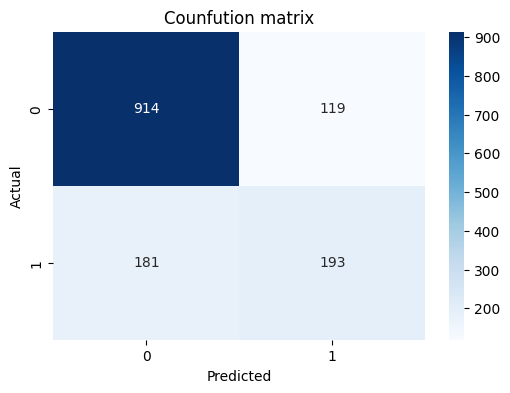

In [8]:
plt.figure(figsize=(6,4))
sns.heatmap(cm , annot=True , fmt="d" , cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Counfution matrix")
plt.show()

In [9]:
import joblib

joblib.dump(model , "churn_model.pkl")
print("Model Saved Successfully!")

Model Saved Successfully!
